In [2]:
import pandas as pd
df_ab_test = pd.read_csv(r"C:\Users\asus\Documents\CaseStudies-main\AB Testing\ab_test_click_data.csv")

N_con = df_ab_test[df_ab_test["group"] == "con"].count()
N_exp = df_ab_test[df_ab_test["group"] == "exp"].count()

# calculating the total number of clicks per grou by summing 1's
X_con = df_ab_test.groupby("group")["click"].sum().loc["con"]
X_exp = df_ab_test.groupby("group")["click"].sum().loc["exp"]


# printing this for visibility
print(df_ab_test.groupby("group")["click"].sum())
print("Number of user in Control: ", N_con)
print("Number of user in Experimental: ", N_exp)
print("Number of clicks in Control: ", X_con)
print("Number of clicks in Experimental: ", X_exp)

group
con    1989
exp    6116
Name: click, dtype: int64
Number of user in Control:  user_id      10000
click        10000
group        10000
timestamp        0
dtype: int64
Number of user in Experimental:  user_id      10000
click        10000
group        10000
timestamp    10000
dtype: int64
Number of clicks in Control:  1989
Number of clicks in Experimental:  6116


In [3]:
import pandas as pd
df_ab_test = pd.read_csv(r"C:\Users\asus\Documents\CaseStudies-main\AB Testing\ab_test_click_data.csv")

X_con = df_ab_test.groupby("group")["click"].sum().loc["con"]
X_exp = df_ab_test.groupby("group")["click"].sum().loc["exp"]

N_con = df_ab_test[df_ab_test["group"] == "con"].count()
N_exp = df_ab_test[df_ab_test["group"] == "exp"].count()

# computing the estimate of click probability per group 
p_con_hat = X_con/N_con
p_exp_hat = X_exp/N_exp
print("Click Probability in Control Group:", p_con_hat)
print("Click Probability in Experimental Group:", p_exp_hat)

# computing the estimate of pooled click probability 
p_pooled_hat = (X_con+X_exp) / (N_con+N_exp) 

Click Probability in Control Group: user_id      0.1989
click        0.1989
group        0.1989
timestamp       inf
dtype: float64
Click Probability in Experimental Group: user_id      0.6116
click        0.6116
group        0.6116
timestamp    0.6116
dtype: float64


In [4]:
# computing the estimate of click probability per group
p_con_hat = X_con / N_con  
p_exp_hat = X_exp / N_exp  
print("Click Probability in Control Group:", p_con_hat)
print("Click Probability in Experimental Group:", p_exp_hat)

# computing the estimate of pooled clicked probability
p_pooled_hat = (X_con+X_exp) / (N_con+N_exp) 
print("Pooled Click Probability:", p_pooled_hat)

Click Probability in Control Group: user_id      0.1989
click        0.1989
group        0.1989
timestamp       inf
dtype: float64
Click Probability in Experimental Group: user_id      0.6116
click        0.6116
group        0.6116
timestamp    0.6116
dtype: float64
Pooled Click Probability: user_id      0.40525
click        0.40525
group        0.40525
timestamp    0.81050
dtype: float64


In [5]:
# computing the estimate of pooled variance
pooled_variance = p_pooled_hat * (1-p_pooled_hat) * (1/N_con + 1/N_exp)
print("p^_pooled is: ", p_pooled_hat)
print("pooled_variance is: ", pooled_variance) 

p^_pooled is:  user_id      0.40525
click        0.40525
group        0.40525
timestamp    0.81050
dtype: float64
pooled_variance is:  user_id      0.000048
click        0.000048
group        0.000048
timestamp         inf
dtype: float64


In [6]:
import numpy as np
from scipy.stats import norm

alpha = 0.05

# computing the standard error of the test
SE = np.sqrt(pooled_variance)
print("Standard Error is: ", SE)

# computing the test statistics of Z-test
Test_stat = (p_con_hat - p_exp_hat)/SE
print("Test Statistics for 2-sample Z-test is:", Test_stat)

# cruritcal value of the Z-test
Z_crit = norm.ppf(1-alpha/2)
print("Z-critical value from Standard Normal distribution: ", Z_crit)

Standard Error is:  user_id      0.006943
click        0.006943
group        0.006943
timestamp         inf
dtype: float64
Test Statistics for 2-sample Z-test is: user_id     -59.441633
click       -59.441633
group       -59.441633
timestamp          NaN
dtype: float64
Z-critical value from Standard Normal distribution:  1.959963984540054


In [40]:
import numpy as np
from scipy.stats import norm

N_con = 10000
N_exp = 10000
X_con = 1989
X_exp = 6116

p_con_hat = X_con / N_con
p_exp_hat = X_exp / N_exp

pooled_variance = 0.006943
SE = np.sqrt(pooled_variance)

p_value = 2 * norm.sf(abs(Test_stat))
Test_stat = (p_con_hat - p_exp_hat) / SE

def is_statistical_significance(p_value, alpha=0.05):
    print(f"P-value of the 2-sample Z-test: {round(p_value, 3)}") 
    if p_value < alpha:
        print:("There is statistical significance")
    else:
        print("There is no statistical significance")

Click Probability in Control Group: 0.1989
Click Probability in Experimental Group: 0.6116
Standard Error is: 0.2974502339386658
Test Statistics for 2-sample Z-test is: -59.44
Z-critical value from Standard Normal distribution: 1.959963984540054


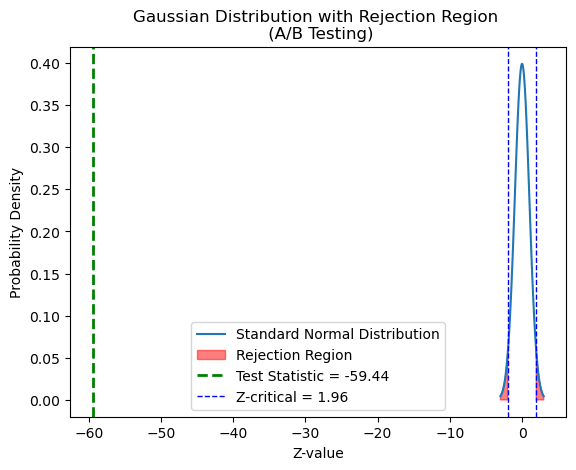

In [31]:
# Parameters for the standard normal distribution
import matplotlib.pyplot as plt

N_con = 10000
N_exp = 10000
X_con = 1989
X_exp = 6116

p_con_hat = X_con / N_con
p_exp_hat = X_exp / N_exp

SE = np.sqrt(pooled_variance)

Test_stat = -59.44

alpha = 0.05
Z_crit = norm.ppf(1 - alpha / 2)

print("Click Probability in Control Group:", p_con_hat)
print("Click Probability in Experimental Group:", p_exp_hat)
print("Standard Error is:", SE)
print("Test Statistics for 2-sample Z-test is:", Test_stat)
print("Z-critical value from Standard Normal distribution:", Z_crit)

mu = 0     # mean
sigma = 1  # standard deviation
x = np.linspace(mu - 3*sigma, mu +3*sigma, 100)
y = norm.pdf(x, mu, sigma)

# Plotting the standadr normal distribution
plt.plot(x, y, label='Standard Normal Distribution')
# Shade the rejection region for a two-tailed test
plt.fill_between(x, y, where=(x > Z_crit) | (x < -Z_crit), color='red', alpha=0.5, label='Rejection Region')
# Adding test statistic
plt.axvline(Test_stat, color='green', linestyle='dashed', linewidth=2, label=f'Test Statistic = {Test_stat:.2f}')
# Adding Z-critical values
plt.axvline(Z_crit, color='blue', linestyle='dashed', linewidth=1, label=f'Z-critical = {Z_crit:.2f}')
plt.axvline(-Z_crit, color='blue', linestyle='dashed', linewidth=1)   
            
# Adding label and title
plt.xlabel('Z-value')
plt.ylabel('Probability Density')
plt.title('Gaussian Distribution with Rejection Region \n (A/B Testing)')
plt.legend()
# Show plot
plt.show()

In [43]:
# Calculate the Confidence Interval (CI) for a 2-sample Z-test
## Calculate the lower and upper bounds of the confidence interval
CI = [
    round((p_exp_hat - p_con_hat) - SE*Z_crit, 3),
    round((p_exp_hat - p_con_hat) + SE*Z_crit, 3)
]

# Print the calculated confidence interfal
print("Confidence interfal of the 2 sample Z-test is: ", CI)

Confidence interfal of the 2 sample Z-test is:  [0.249, 0.576]


In [ ]:
def_is_Practically_significant(delta, CI_95):
    
    # Extract lower bound for Confidence Interval 
    lower_bound_CI = CI_95(0)
    
    # Check if the lower bound of the CI is greater than or equal to delta
    if lower_bound_CI >= delta:
        print(f"We have practical significance! n\With MDE of {delta},The difference between Control and Experimental group is not practically significant.")
        return True
    else:
        print("We don't have significance! n\The difference between Control and Experimental group is not practically significant.") 
        return False
              
    # Example of using the function
    delta = 0.05
    CI_95 = (0.04, 0.06)
    

              